In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


file_path = "Day13_Restaurant_Branch_Performance_Dataset.csv"
df = pd.read_csv(file_path)


display(df.head())




,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 1

In [2]:
display(df.describe().T)

missing_vals = df.isnull().sum()

print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found.")


duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

for col in df.select_dtypes(include=["object", "category"]).columns:
    print(f"{col}: {df[col].nunique()} unique categories ({df[col].unique()})")

--- SUMMARY STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
Staff_Count,350.0,11.957143,4.338261,5.00,9.0000,11.000,15.0000,24.00
Marketing_Spend,350.0,5516.347743,2050.906967,725.35,4339.7275,5393.370,6748.5025,11784.96
Customers,350.0,217.377143,56.722524,77.00,180.2500,213.000,255.7500,360.00
Orders,350.0,187.054286,50.558371,71.00,155.0000,182.500,218.7500,334.00
Average_Bill,350.0,388.906371,82.488196,180.00,337.3150,383.485,441.7650,623.28
Revenue,350.0,86831.799657,36644.453901,20540.76,61261.7175,79766.880,102976.1850,194018.92
Food_Cost,350.0,31807.545114,13896.888942,7262.01,22326.6625,28861.325,38370.3700,75946.59
Operating_Cost,350.0,56621.444486,18467.842215,20782.38,43797.6700,53723.025,63961.2275,111489.14
Profit,350.0,30210.355171,19508.592192,-6924.68,16915.4925,26873.870,39823.7425,89096.19
Avg_Delivery_Min,350.0,26.098857,4.388125,13.90,22.8000,26.100,29.0750,38.30



--- MISSING VALUES PER COLUMN ---
Promotion    184
dtype: int64

Duplicate Rows: 0

--- UNIQUE COUNTS PER CATEGORICAL VARIABLE ---
Record_ID: 350 unique categories (['ST0001' 'ST0002' 'ST0003' 'ST0004' 'ST0005' 'ST0006' 'ST0007' 'ST0008'
 'ST0009' 'ST0010' 'ST0011' 'ST0012' 'ST0013' 'ST0014' 'ST0015' 'ST0016'
 'ST0017' 'ST0018' 'ST0019' 'ST0020' 'ST0021' 'ST0022' 'ST0023' 'ST0024'
 'ST0025' 'ST0026' 'ST0027' 'ST0028' 'ST0029' 'ST0030' 'ST0031' 'ST0032'
 'ST0033' 'ST0034' 'ST0035' 'ST0036' 'ST0037' 'ST0038' 'ST0039' 'ST0040'
 'ST0041' 'ST0042' 'ST0043' 'ST0044' 'ST0045' 'ST0046' 'ST0047' 'ST0048'
 'ST0049' 'ST0050' 'ST0051' 'ST0052' 'ST0053' 'ST0054' 'ST0055' 'ST0056'
 'ST0057' 'ST0058' 'ST0059' 'ST0060' 'ST0061' 'ST0062' 'ST0063' 'ST0064'
 'ST0065' 'ST0066' 'ST0067' 'ST0068' 'ST0069' 'ST0070' 'ST0071' 'ST0072'
 'ST0073' 'ST0074' 'ST0075' 'ST0076' 'ST0077' 'ST0078' 'ST0079' 'ST0080'
 'ST0081' 'ST0082' 'ST0083' 'ST0084' 'ST0085' 'ST0086' 'ST0087' 'ST0088'
 'ST0089' 'ST0090' 'ST0091' 'ST

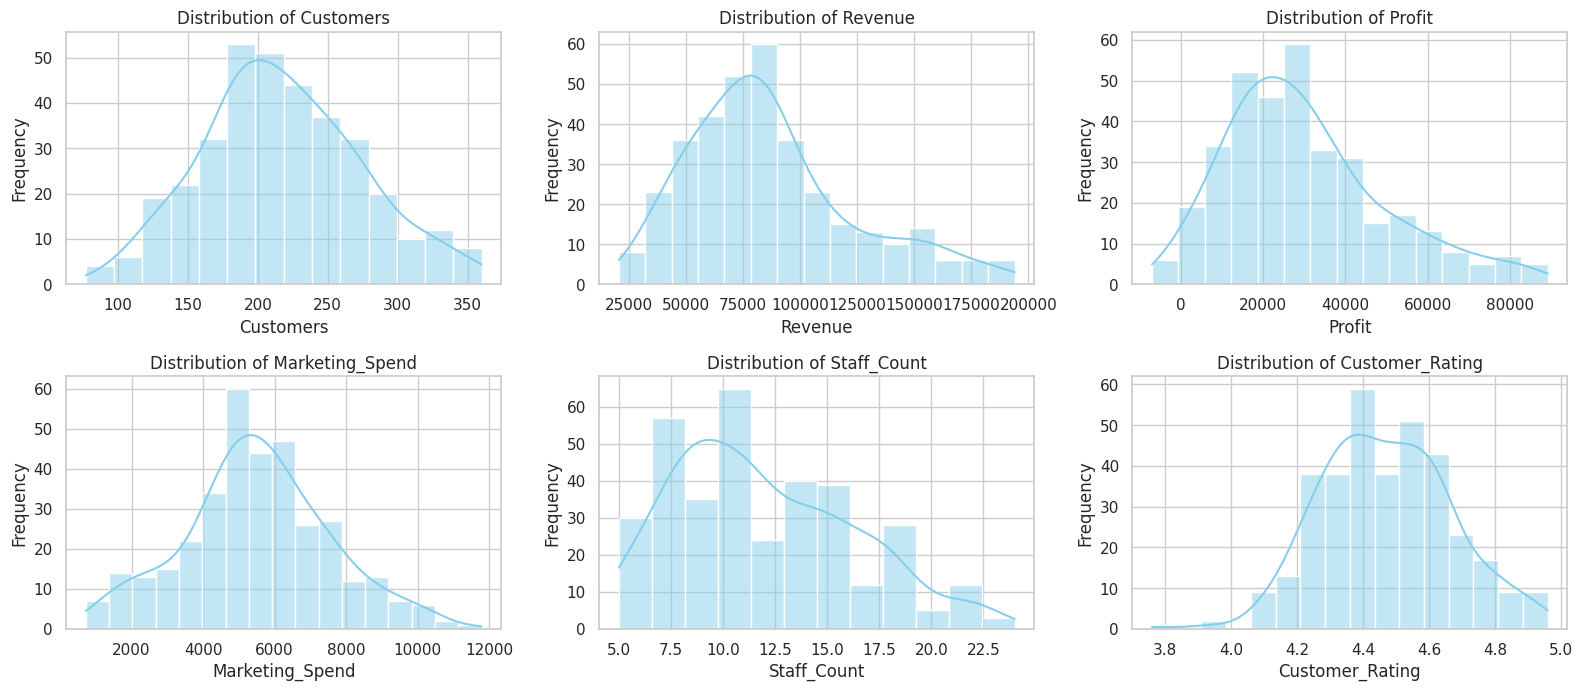

In [3]:

num_cols = ["Customers", "Revenue", "Profit", "Marketing_Spend", "Staff_Count", "Delivery_Time", "Customer_Rating"]
num_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

--- AVERAGE METRICS BY REGION ---


,Region,Revenue,Profit,Customers,Customer_Rating
0,North,86946.939470,30625.960833,217.651515,4.477424
1,South,88320.217518,30690.568102,218.934307,4.450803
2,West,84126.716914,28720.859877,214.296296,4.487407


/tmp/ipykernel_2663/485863761.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf, x="Region", y="Revenue", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_2663/485863761.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf, x="Region", y="Profit", ax=axes[1], palette="Greens_d")


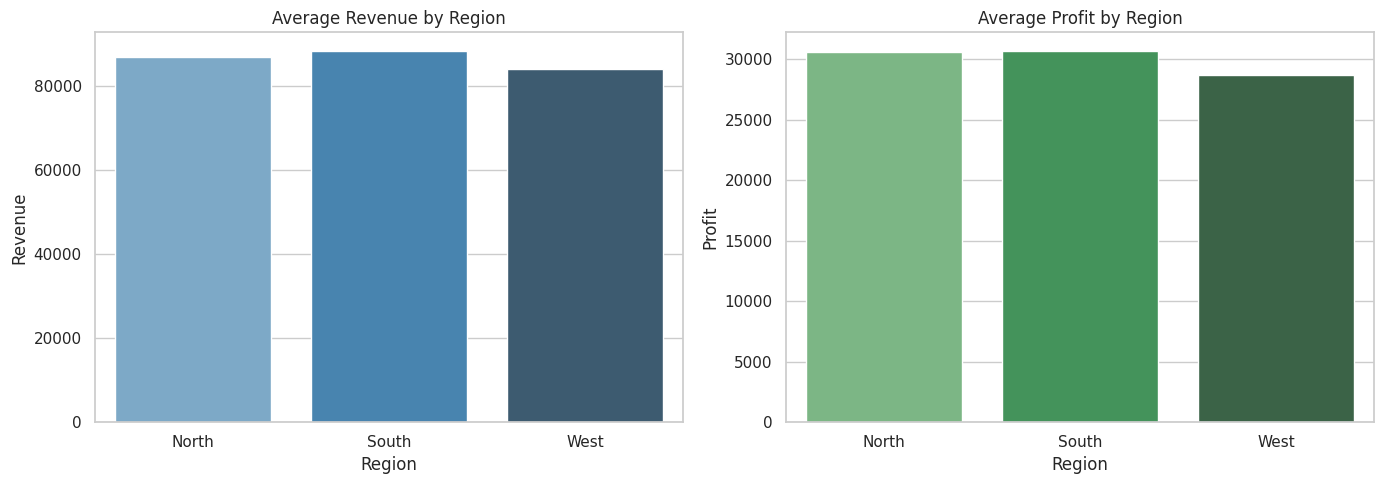

-- AVERAGE METRICS BY STORE TYPE ---


,Store_Type,Revenue,Profit,Avg_Delivery_Min,Customer_Rating
0,Express,52327.164804,12742.137941,26.171569,4.465000
1,Premium,152867.313269,62890.235385,26.400000,4.458654
2,Standard,87268.667245,30630.785714,25.981122,4.474388


/tmp/ipykernel_2663/485863761.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Store_Type", y="Revenue", ax=axes[0], palette="Set2")
/tmp/ipykernel_2663/485863761.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Store_Type", y="Avg_Delivery_Min", ax=axes[1], palette="Set2")


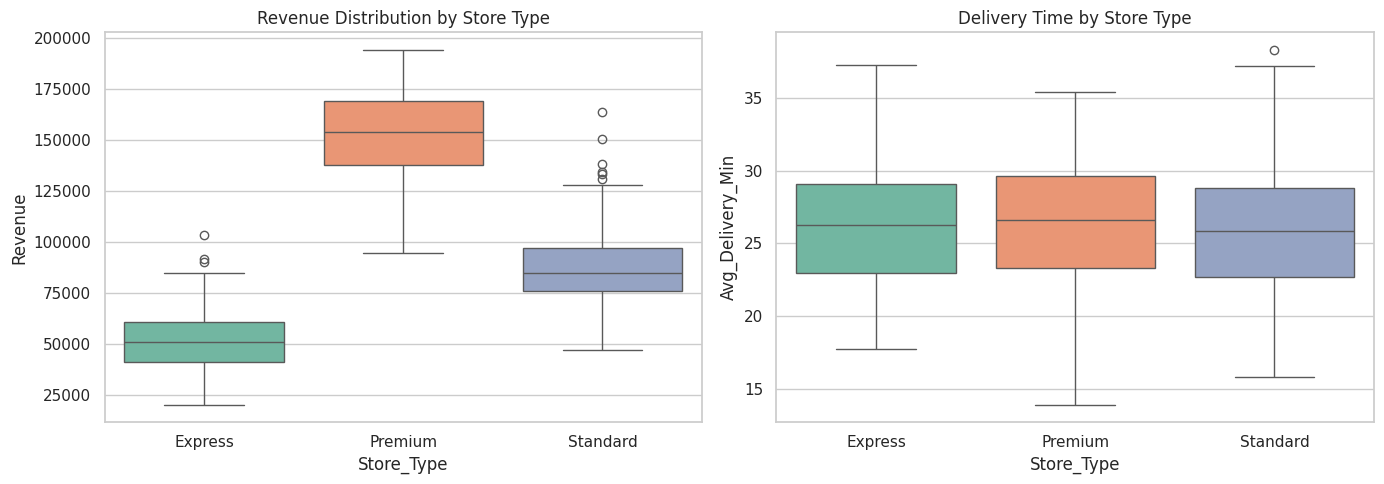

In [6]:

if "Region" in df.columns:
    region_perf = df.groupby("Region")[["Revenue", "Profit", "Customers", "Customer_Rating"]].mean().reset_index()
    print("--- AVERAGE METRICS BY REGION ---")
    display(region_perf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=region_perf, x="Region", y="Revenue", ax=axes[0], palette="Blues_d")
    axes[0].set_title("Average Revenue by Region")

    sns.barplot(data=region_perf, x="Region", y="Profit", ax=axes[1], palette="Greens_d")
    axes[1].set_title("Average Profit by Region")
    plt.tight_layout()
    plt.show()

if "Store_Type" in df.columns:
    store_perf = df.groupby("Store_Type")[["Revenue", "Profit", "Avg_Delivery_Min", "Customer_Rating"]].mean().reset_index()
    print("-- AVERAGE METRICS BY STORE TYPE ---")
    display(store_perf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=df, x="Store_Type", y="Revenue", ax=axes[0], palette="Set2")
    axes[0].set_title("Revenue Distribution by Store Type")

    sns.boxplot(data=df, x="Store_Type", y="Avg_Delivery_Min", ax=axes[1], palette="Set2")
    axes[1].set_title("Delivery Time by Store Type")
    plt.tight_layout()
    plt.show()

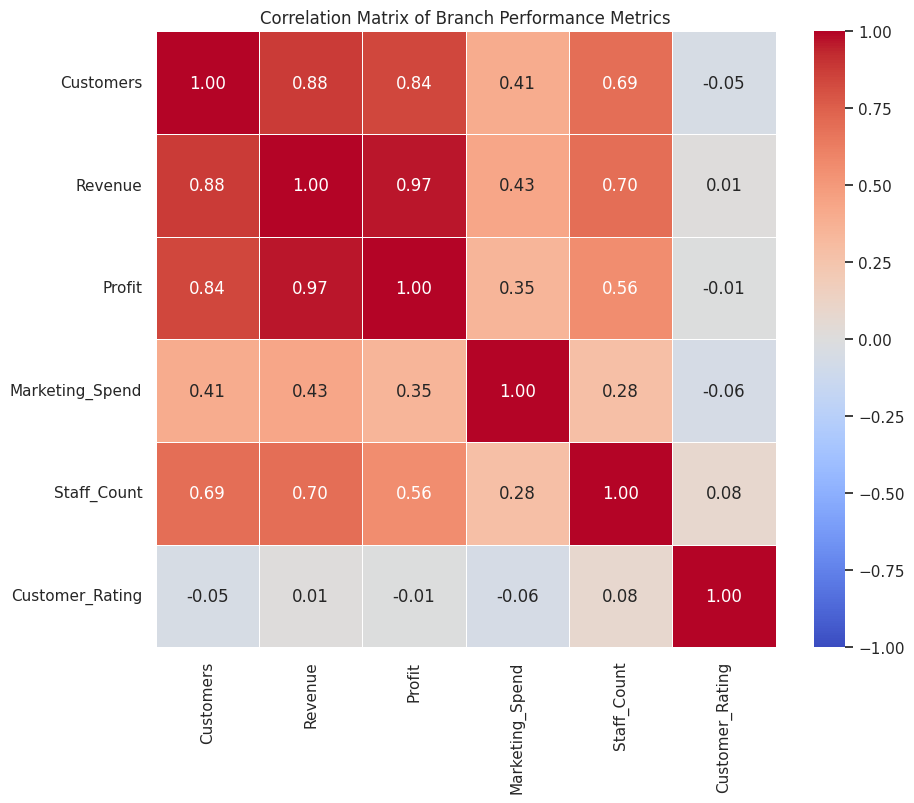

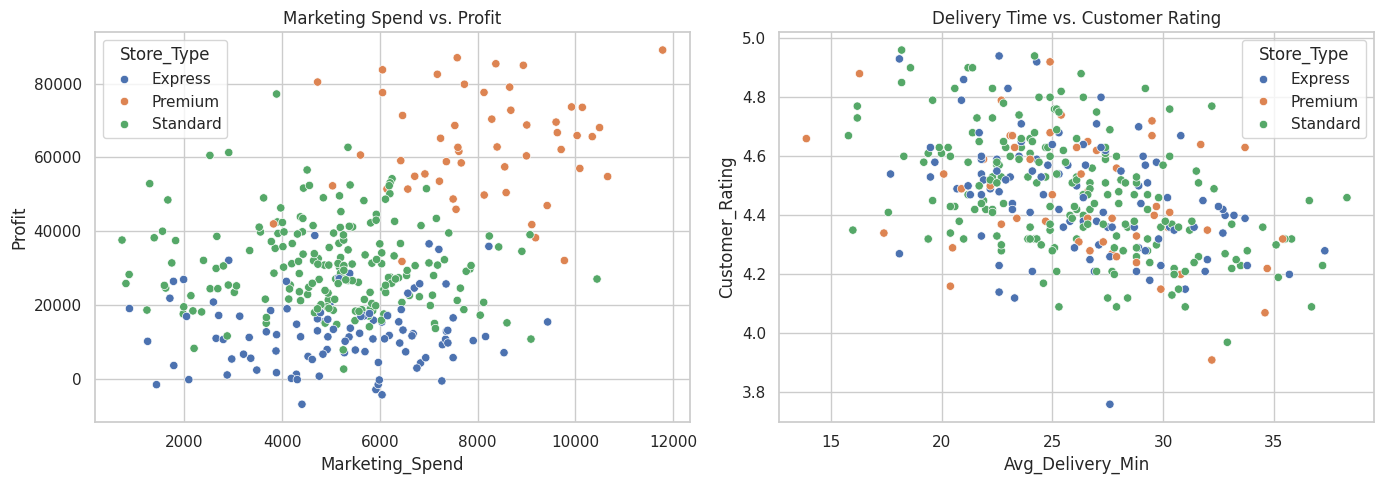

In [8]:
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Branch Performance Metrics")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.scatterplot(data=df, x="Marketing_Spend", y="Profit", hue="Store_Type" if "Store_Type" in df.columns else None, ax=axes[0])
axes[0].set_title("Marketing Spend vs. Profit")


sns.scatterplot(data=df, x="Avg_Delivery_Min", y="Customer_Rating", hue="Store_Type" if "Store_Type" in df.columns else None, ax=axes[1])
axes[1].set_title("Delivery Time vs. Customer Rating")

plt.tight_layout()
plt.show()